# 1a. Introduction to Network Science

Welcome to the first practical of the Network Science Summer School!

## Learning objectives
By the end of this notebook you will be able to:
1. Recognise the most common file formats for network data and load them with `igraph`.
2. Build a network from an adjacency list (e.g. a TSV file), and a GraphML file.
3. Visualise networks using different layouts and visual encodings.
4. Describe a network with summary statistics (components, diameter, density, clustering, assortativity, robustness).
5. Plot degree, triangle, clustering and path-length distributions.
6. Compare an observed metric against random reference models (ER, configuration, Barabasi-Albert) and run a permutation test for attribute assortativity.

## Section index
- **Section 0**: Setup
- **Section 1**: Network data formats
- **Section 2**: Build a network from raw data
- **Section 3**: Visualizing networks
- **Section 4**: Describing networks
- **Section 5**: Distributions
- **Section 6**: Reference models and permutation test


In [1]:
# On Colab, uncomment the following lines to install the required packages
# and to clone the course repository with the data:
# !pip install python-igraph networkx pandas numpy matplotlib seaborn
# !git clone https://github.com/jgarciab/NetworkScience.git
# import sys
# sys.path.append('/content/NetworkScience/Practicals/day1/')

In [2]:
# Path to the data folder
# On your computer:
path_data = "../../Data/"
# On Colab uncomment:
# path_data = "/content/NetworkScience/Data/"


In [3]:
# Core libraries
import igraph as ig    # Primary network library for this practical
import networkx as nx  # Used only for the florentine_families convenience constructor

# Data and numerics
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Helper functions (currently networkx-based; we'll port what we need inline)
import sys
sys.path.append("./")
# from common_functions import *  # Available if you want to peek at the originals

# Visual style for the whole notebook
custom_params = {
    "axes.spines.right": False, "axes.spines.top": False, "axes.spines.left": False, "axes.spines.bottom": False,
    "lines.linewidth": 2, "grid.color": "lightgray", "legend.frameon": False,
    "xtick.labelcolor": "#484848", "ytick.labelcolor": "#484848",
    "xtick.color": "#484848", "ytick.color": "#484848",
    "text.color": "#484848", "axes.labelcolor": "#484848",
    "axes.titlecolor": "#484848", "figure.figsize": [5, 3],
    "axes.titlelocation": "left",
    "xaxis.labellocation": "left",
    "yaxis.labellocation": "bottom",
}
palette = ["#3d348b", "#e6af2e", "#191716", "#e0e2db"]
sns.set_theme(context='paper', style='white', palette=palette, font_scale=1.3, color_codes=True, rc=custom_params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
# Reproducibility seeds (igraph layouts use python's random, numpy used elsewhere)
import random
random.seed(1)
np.random.seed(1)


---

## Section 1: Network data formats

A network is, fundamentally, just a list of who-relates-to-whom. The same network can be stored on disk in many different formats. In this section we look at the four formats you are most likely to encounter:

| Format | Extension | Best for |
|--------|-----------|----------|
| Edgelist | `.csv`, `.tsv`, `.txt` | Sharing, scraping, quick imports |
| Adjacency matrix | `.npy`, `.csv` | Linear-algebra views, small dense graphs |
| GraphML / GML / Pajek | `.graphml`, `.gml`, `.net` | Keeping node/edge attributes, interop with Gephi, Cytoscape, R |
| JSON | `.json` | Web visualisations (d3.js, vis.js, cytoscape.js) |


### 1.1 Edgelist (CSV / TSV)

The most human-readable way to describe a network: each row is one edge.

```
source,target
Alice,Bob
Alice,Carol
Bob,Dave
...
```

In `igraph` we typically build a graph from an edgelist reading it with pandas and using `ig.Graph.DataFrame()`


In [4]:
# Small change to try: add one extra pair to `toy_edges` and rerun.
toy_edges = [
    ("Alice", "Bob"),
    ("Alice", "Carol"),
    ("Bob", "Dave"),
    ("Carol", "Dave"),
    ("Dave", "Eve"),
    ("Eve", "Frank"),
]

# Showing the edge list as a pandas dataframe
edges_df = pd.DataFrame(toy_edges, columns=["source", "target"])
display(edges_df)

# Creating the network from an edgelist
g_toy = ig.Graph.DataFrame(edges_df, 
                           directed=False,
                           use_vids=False
                          )

# Printing the number of nodes (vcount) and edges (ecount)
print("Nodes:", g_toy.vs["name"])
print(f"n = {g_toy.vcount()}, m = {g_toy.ecount()}")

,source,target
0,Alice,Bob
1,Alice,Carol
2,Bob,Dave
3,Carol,Dave
4,Dave,Eve
5,Eve,Frank


Nodes: ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank']
n = 6, m = 6


### 1.2 Adjacency matrix view

The same network can be written as a square 0/1 matrix where `A[i, j] = 1` iff there is an edge between node `i` and node `j`. This view is convenient for linear algebra and spectral methods.


<6x6 sparse matrix of type '<class 'numpy.int64'>'
	with 12 stored elements in Compressed Sparse Row format>

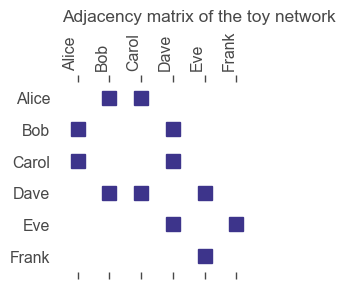

In [5]:
## Sparse matrix
A = g_toy.get_adjacency_sparse()
display(A)

fig, ax = plt.subplots(figsize=(3, 3))
plt.spy(A) # plot the sparse matrix
ax.set_xticks(range(g_toy.vcount()))
ax.set_yticks(range(g_toy.vcount()))
ax.set_xticklabels(g_toy.vs["name"], rotation=90, ha="right")
ax.set_yticklabels(g_toy.vs["name"])
ax.set_title("Adjacency matrix of the toy network")
plt.tight_layout()
plt.show()

array([[0, 1, 1, 0, 0, 0],
       [1, 0, 0, 1, 0, 0],
       [1, 0, 0, 1, 0, 0],
       [0, 1, 1, 0, 1, 0],
       [0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 1, 0]])

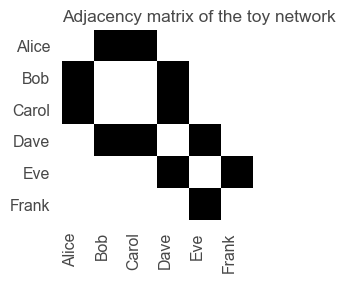

In [6]:
# Dense adjacency matrix (small networks only!)
A = np.array(g_toy.get_adjacency().data)
display(A)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(A, cmap="Greys")
ax.set_xticks(range(g_toy.vcount()))
ax.set_yticks(range(g_toy.vcount()))
ax.set_xticklabels(g_toy.vs["name"], rotation=90, ha="right")
ax.set_yticklabels(g_toy.vs["name"])
ax.set_title("Adjacency matrix of the toy network")
plt.tight_layout()
plt.show()


### 1.3 Interchange formats: GraphML, GML, Pajek, JSON

When you want to keep **node and edge attributes** (labels, weights, types, positions, ...) alongside the edges, a plain CSV is no longer enough. The most common richer formats are:

- **GraphML** (`.graphml`): XML-based, very widely supported (Gephi, Cytoscape, networkx, igraph).
- **GML** (`.gml`): Simpler text format, used historically by Pajek and many classic datasets.
- **JSON** (e.g. node-link JSON): The format of choice for web visualisations.

`igraph` reads all of these out of the box.

EXERCISE: 
* Open `medici.gml` and `ppi_network_prediction.graphml` in a text editor.
* Explore the code below

In [7]:
g_gml = ig.Graph.Read_GML(f"{path_data}/medici.gml")
g_graphml = ig.Graph.Read_GraphML(f"{path_data}/ppi_network_prediction.graphml")

print(f"medici.gml : n = {g_gml.vcount()}, m = {g_gml.ecount()}")
print(f"ppi.graphml: n = {g_graphml.vcount()}, m = {g_graphml.ecount()}")
print("GraphML vertex attributes:", g_graphml.vs.attributes())

# Writing to a different format is also easy
tmp_path = "/tmp/_roundtrip.graphml"
g_gml.write_graphml(tmp_path)

medici.gml : n = 16, m = 35
ppi.graphml: n = 964, m = 1202
GraphML vertex attributes: ['label', 'id']


In [8]:
# You can see the adjacency list
g_gml.get_edge_dataframe().head()

# and the node properties
g_gml.get_vertex_dataframe().head()


,id,_pos,name,nodeLabel
vertex ID,,,,
0,0.0,"3.9477401370487888, 1.2719081581250928",ACCIAIUOL,ACCIAIUOL
1,1.0,"4.0067822619703701, 1.2437653936176905",ALBIZZI,ALBIZZI
2,2.0,"4.043183169548703, 1.2405760262335446",BARBADORI,BARBADORI
3,3.0,"4.0625603524127865, 1.1762726437875137",BISCHERI,BISCHERI
4,4.0,"4.0878154738110277, 1.2303612841732443",CASTELLAN,CASTELLAN


---

## Section 2: Build real networks



### 2.1 From a pandas DataFrame (Google Sheets URL)

We collected a small network during the warm-up game. The data lives in a Google Sheet, published as CSV. We can read it straight into pandas and convert to an `igraph` graph.

Network here: <https://tinyurl.com/network-game>


,P1,P2,Reason
0,Javier,Leto,organized conference


n = 2, m = 1


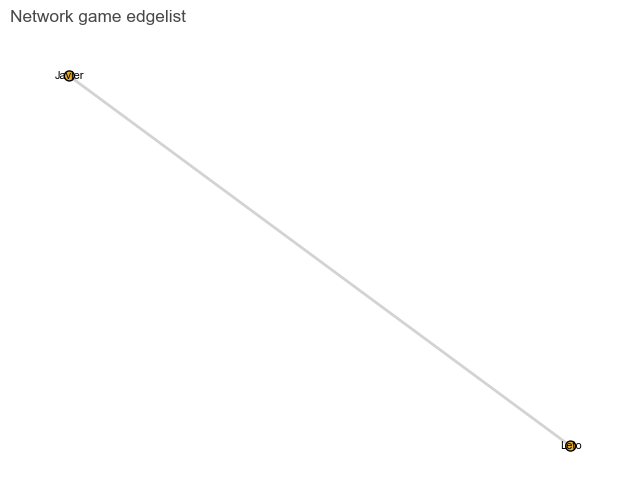

In [9]:
# Student scaffold: load an edgelist and turn it into a graph.
# Small change to try: set `show_labels = False` if the labels overlap.
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vSuZC86KjXYKSPr0Nw7mfRha4zwea3aMw-gTKliVcbRt_m3NRiCEyxbH_d5M8MBL0LWayg1WDmnqBET/pub?gid=0&single=true&output=csv"
show_labels = True

# read edgelist
df = pd.read_csv(url)
edge_columns = ["P1", "P2"]
display(df.head())

# convert to igraph
G_game = ig.Graph.DataFrame(df[edge_columns], use_vids=False, directed=False)
print(f"n = {G_game.vcount()}, m = {G_game.ecount()}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
layout = G_game.layout_fruchterman_reingold()
ig.plot(
    G_game, target=ax, layout=layout,
    vertex_size=10, vertex_color="#e6af2e",
    edge_color="lightgray",
    vertex_label=G_game.vs["name"] if show_labels else None,
    vertex_label_size=8,
)
ax.set_title("Network game edgelist")
plt.show()


### 2.2 Twitter network (TSV edgelist)

`ic2s2_netsci_3.tsv` is a small mention/reply/retweet network collected around the IC2S2 and NetSci conferences. It is a plain TSV with `source` and `target` columns.


,source,target,id,type,time,retweet_count,reply_count,like_count,quote_count,platform,year,number_years
Unnamed: 0,,,,,,,,,,,,
3,dse_msu,IC2S2,1518792519558987776,mentioned,2022-04-26 03:22:09+00:00,0,0,10,0,Twitter Web App,2022.0,3.0
9,barabasi,Gfalbery,1517457062220992513,mentioned,2022-04-22 10:55:31+00:00,8,0,9,1,Twitter Web App,2022.0,7.0
14,MencheLab,zkmkarlsruhe,1513170001196457986,mentioned,2022-04-10 15:00:16+00:00,2,0,6,0,Hootsuite Inc.,2022.0,3.0
19,IC2S2,IC2S2,1498679310034608145,mentioned,2022-03-01 15:19:26+00:00,0,0,1,0,Twitter Web App,2022.0,8.0
20,aliceschwarze,arikan,1487902362236821504,mentioned,2022-01-30 21:35:41+00:00,22,2,98,3,Twitter Web App,2022.0,5.0


Twitter: n = 1554, m = 52840


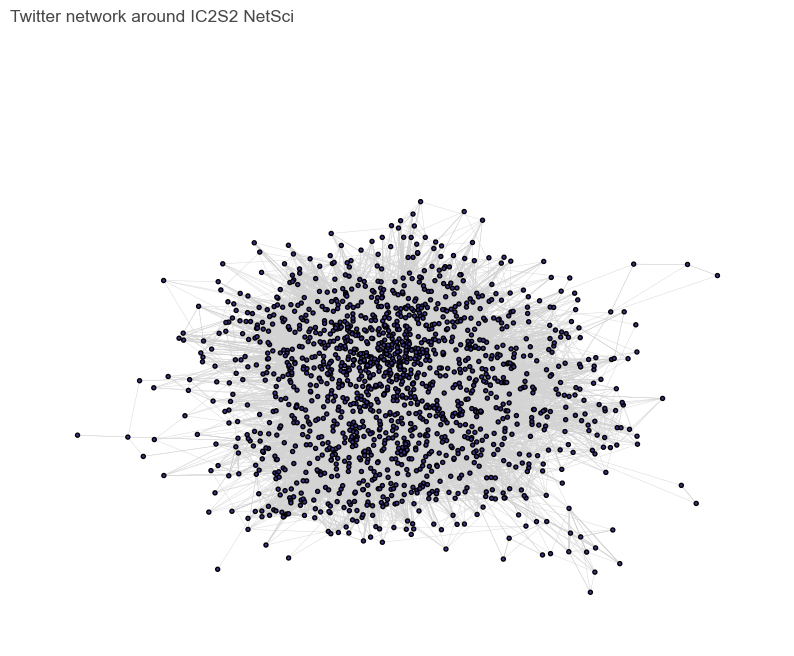

In [10]:
# Small change to try: switch `directed` to True and compare n/m.
directed = False
df_tw = pd.read_csv(f"{path_data}/ic2s2_netsci_3.tsv", sep="\t", index_col=0)
display(df_tw.head())

G_twitter = ig.Graph.DataFrame(
    df_tw[["source", "target"]],
    use_vids=False,
    directed=directed,
)
G_twitter.simplify(multiple=False, loops=True)
print(f"Twitter: n = {G_twitter.vcount()}, m = {G_twitter.ecount()}")

fig, ax = plt.subplots(figsize=(10, 8))
layout = G_twitter.layout_fruchterman_reingold()
ig.plot(
    G_twitter, target=ax, layout=layout,
    vertex_size=4, vertex_color="#3d348b",
    edge_color="lightgray", edge_width=0.3,
)
ax.set_title("Twitter network around IC2S2 NetSci")
plt.show()


### 2.3 Protein-Protein Interaction (PPI) network (GraphML)

`ppi_network_prediction.graphml` is a small yeast Protein-Protein Interaction network. Because it is already a GraphML file, we get nodes and attributes for free.


PPI: n = 964, m = 1202


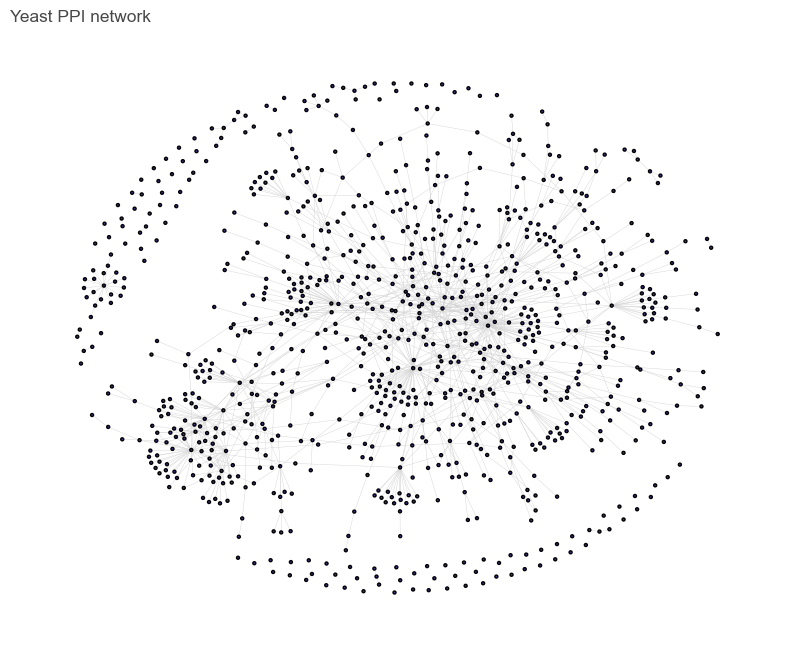

In [11]:
# Read the network
G_ppi = ig.Graph.Read_GraphML(f"{path_data}/ppi_network_prediction.graphml")
G_ppi.to_undirected(mode="collapse")
print(f"PPI: n = {G_ppi.vcount()}, m = {G_ppi.ecount()}")

fig, ax = plt.subplots(figsize=(10, 8))
layout = G_ppi.layout_fruchterman_reingold()
ig.plot(
    G_ppi, target=ax, layout=layout,
    vertex_size=3, vertex_color="#3d348b",
    vertex_label=None,
    edge_color="lightgray", edge_width=0.3
)
ax.set_title("Yeast PPI network")
plt.show()


---

> **Bring your own data**
>
> The patterns above (load a CSV -> build a graph -> visualise) work for **any** edgelist. If you brought your own data, this is a good moment to load it:
>
> 1. Save your edges as a 2-column CSV with header `source,target`.
> 2. Use the pattern from Section 2.1 to read it.
> 3. Visualise it with `ig.plot`.
>
> Try this with your own network before moving on.


In [12]:
# (Optional) Paste your own loading code below
# G_mine = ig.Graph.DataFrame(pd.read_csv("my_data.csv"), use_vids=False, directed=False)



---

## Section 3: Visualizing networks

A good plot of a network can be incredibly illuminating - and a bad plot can be actively misleading.  The same graph can look completely different depending on the layout algorithm. 



### 3.1 The hairball problem

When a network has thousands of edges, layouts produce an unreadable blob (a "hairball"). Let's see this with the Wikipedia voting network.


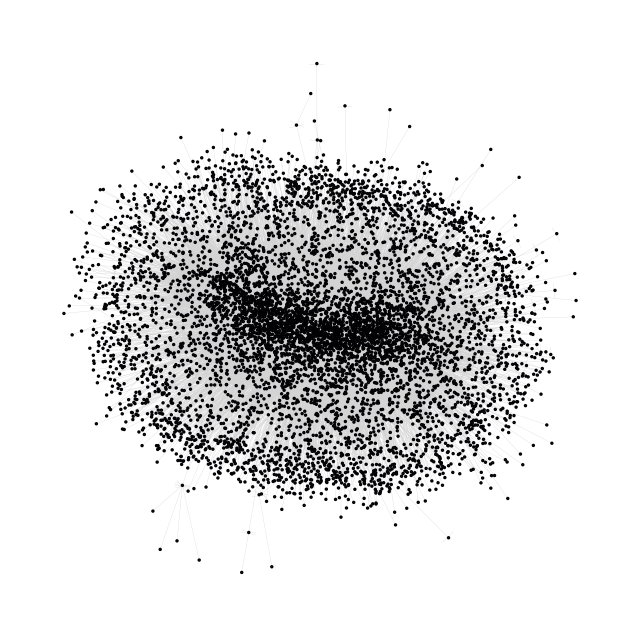

In [13]:
# Student scaffold: load the Wiki-Vote edgelist and deliberately make a bad plot.
# Small change to try: change `layout_random()` to `layout_fruchterman_reingold()`.
# Load directed Wiki-Vote network
df_wiki = pd.read_csv(
    f"{path_data}/wiki-Vote.txt",
    sep="\t", comment="#", header=None,
    names=["source", "target"],
)
G_wiki = ig.Graph.DataFrame(df_wiki, use_vids=False, directed=True)

# Keep only the largest weakly connected component (otherwise unconnected components fly away)
G_lcc = G_wiki.connected_components(mode="weak").giant()

# Plot with a force-directed layout
fig, ax = plt.subplots(figsize=(8, 8))
ig.plot(
    G_lcc,
    target=ax,
    layout=G_lcc.layout_fruchterman_reingold(),
    vertex_size=2, vertex_color="#3d348b",
    edge_color="lightgray", edge_width=0.1, edge_arrow_size=0
)

ax.axis("off")
plt.show()

### 3.2 Visual encoding: size and colour carry information

A plain plot of a network only shows connectivity. By mapping **node size** to a centrality measure and **node colour** to a community label, we can pack much more information into the same chart.

We use the Karate club network (small enough to see every label).


Karate club: n = 34, m = 78


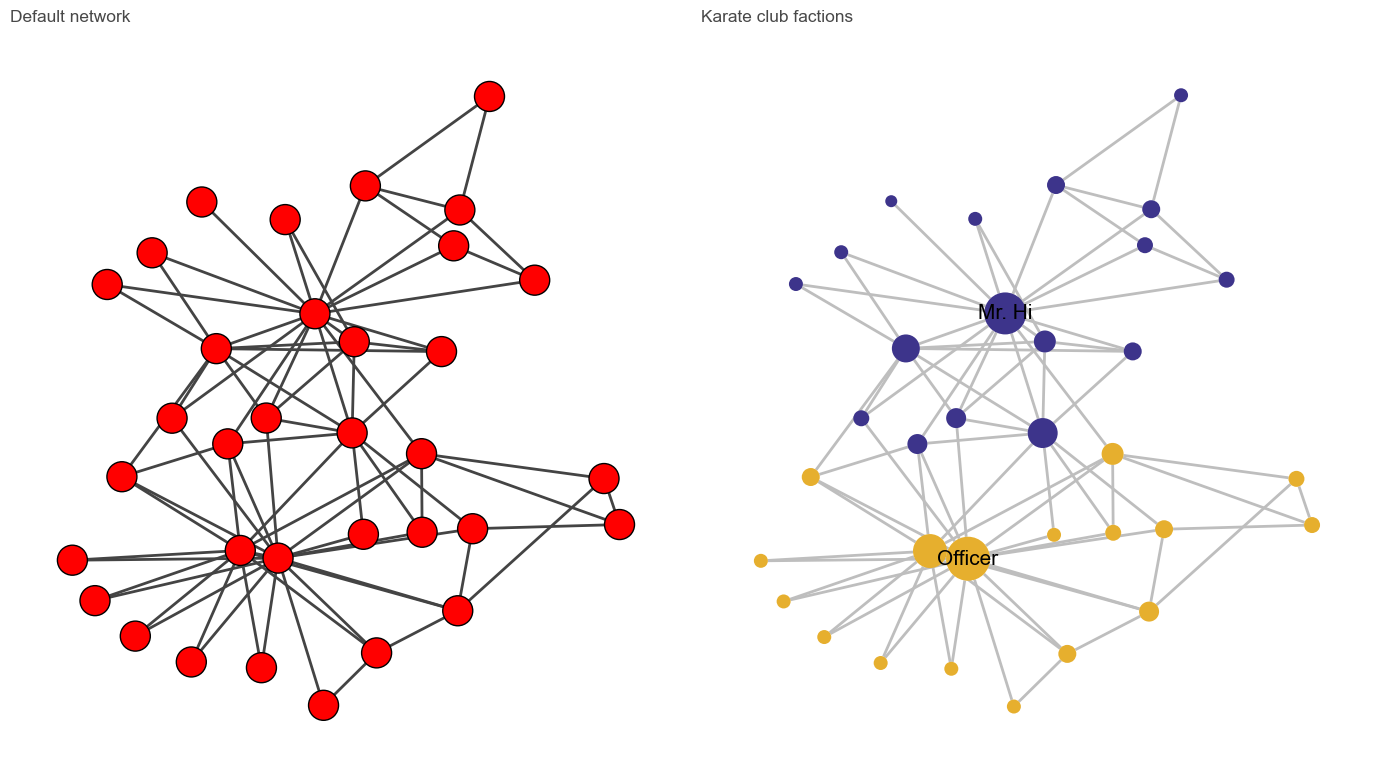

In [14]:
# Karate club: NetworkX -> igraph
# We read it from networkx, another Python library for networks, but a very slow one
G_nx = nx.karate_club_graph()
G_kar = ig.Graph.from_networkx(G_nx, vertex_attr_hashable="name") # convert from networkx to igraph

print(f"Karate club: n = {G_kar.vcount()}, m = {G_kar.ecount()}")

degrees = np.array(G_kar.degree())
layout = G_kar.layout_kamada_kawai()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Left: default network
ig.plot(
    G_kar,
    target=ax1,
    layout=layout
)
ax1.set_title("Default network")

## Improved version

# Color by real club/faction
node_colors = [
    palette[0] if club == "Mr. Hi" else palette[1]
    for club in G_kar.vs["club"]
]

# Label only the two key nodes: 0 = Mr. Hi, 33 = Officer
node_labels = [
    "Mr. Hi" if name == 0 else "Officer" if name == 33 else ""
    for name in G_kar.vs["name"]
]

# Right: faction colors, degree sizes, leader labels
ig.plot(
    G_kar,
    target=ax2,
    layout=layout,
    vertex_color=node_colors,
    vertex_size=list(10 + degrees * 2),
    vertex_label=node_labels,
    vertex_label_size=15,
    vertex_frame_width=0,
    edge_color="gray"
)
ax2.set_title("Karate club factions")

plt.tight_layout()
plt.show()

### 3.4 Visualisation do's and don'ts

**Do**
- Think first about the **main message** you want to communicate. The other points below are contingent on that message.
- Map **node size** to importance (degree, centrality, frequency).
- Map **node colour** to a categorical attribute (community, type, label).
- Use **edge alpha** or thin edges to reduce clutter.
- Pick a **layout** that fits your message (force-directed, circular, hierarchical, ...).
- Label only the **most central** or most interesting nodes.

**Don't**
- Plot a 10-000 node hairball and call it a visualisation.
- Trust the *exact* positions of force-directed layouts - only relative positions are meaningful.


---

## Section 4: Describing networks

Once we have a graph, we want **numbers** that summarise its structure. In this section we compute the classical descriptive statistics on the PPI network and compare to the Twitter network (or your network)


In [15]:
# Small change to try: set `network_choice = "twitter"` after finishing PPI.
network_choice = "twitter"  # options: "ppi", "twitter"
g = G_ppi.copy() if network_choice == "ppi" else G_twitter.copy()
print(f"Working network ({network_choice}): n = {g.vcount()}, m = {g.ecount()}")


Working network (twitter): n = 1554, m = 52840


### 4.1 Connectedness

A *connected component* is a maximal set of nodes such that any two are reachable from each other.


In [16]:
# Only function to notice: `connected_components`.
comps = g.connected_components(mode="weak")
component_sizes = sorted([len(c) for c in comps], reverse=True)
print(f"Number of components: {len(comps)}")
print(f"Sizes of the 20 largest components: {component_sizes[:20]}")

g_lcc = comps.giant()
print(f"Largest component: n = {g_lcc.vcount()}, m = {g_lcc.ecount()}")


Number of components: 1
Sizes of the 20 largest components: [1554]
Largest component: n = 1554, m = 52840


### 4.2 Diameter and average shortest path

- **Diameter**: the longest shortest path between any pair of nodes.
- **Average shortest path**: the mean over all pairs.

Many real-world networks have *very* short paths between nodes ("small world").


In [17]:
print(f"Diameter            : {g_lcc.diameter()}")
print(f"Average path length : {g_lcc.average_path_length():.3f}")


Diameter            : 6
Average path length : 2.518


### 4.3 Density

Density = (edges present) / (edges possible). Most real networks are extremely sparse.


In [18]:
print(f"Density: {g_lcc.density():.5f}")


Density: 0.04379


### 4.4 Transitivity and average clustering

- **Global transitivity** = 3 x (#triangles) / (#connected triples). The "ratio of closed triangles".
- **Average local clustering** = mean local clustering coefficient over nodes.

The two can differ a lot in heterogeneous networks.


In [19]:
# Student scaffold: two ways to summarise triangle closure.
# The function names to notice are `transitivity_undirected` and `transitivity_avglocal_undirected`.
print(f"Global transitivity        : {g_lcc.transitivity_undirected():.4f}")
print(f"Average local clustering   : {g_lcc.transitivity_avglocal_undirected(mode='zero'):.4f}")


Global transitivity        : 0.2134
Average local clustering   : 0.3490


### 4.5 Degree assortativity

Are high-degree nodes connected to other high-degree nodes (assortative, > 0) or to low-degree ones (disassortative, < 0)?


In [20]:
# Student scaffold: degree assortativity asks whether high-degree nodes connect to high-degree nodes.
print(f"Degree assortativity: {g_lcc.assortativity_degree():.4f}")


Degree assortativity: 0.1266


### 4.6 Robustness to failures vs. fragility to targeted attacks

We remove nodes one at a time, either:
- **targeted**: highest-degree node first (think: a smart adversary),
- **random**: uniformly at random (think: random failures).

After each removal we track the share of nodes still in the giant component.


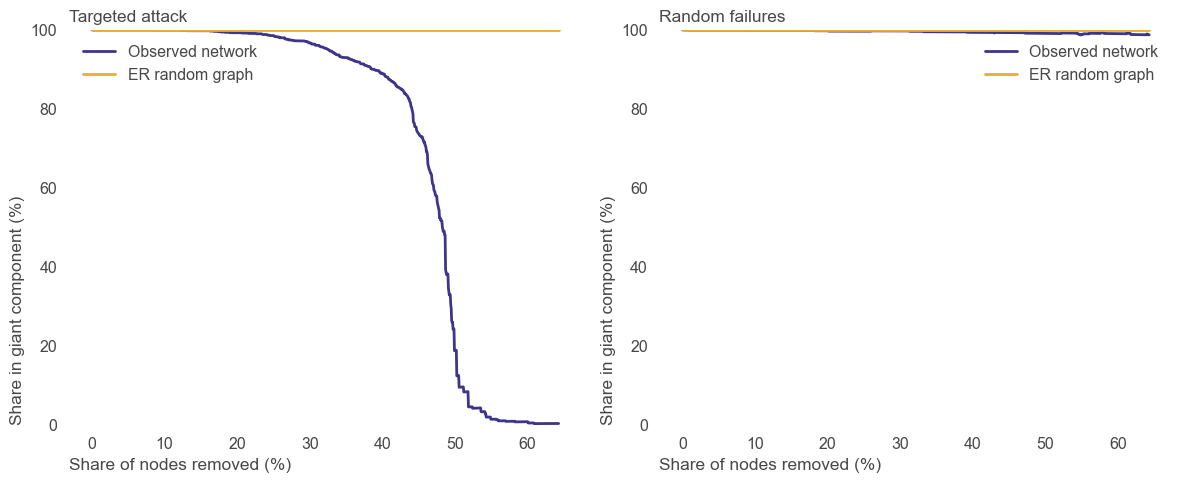

In [21]:
# Small changes to try: set `attack_mode = "random"`, or lower/raise `n_remove`.
def attack_network(g_in, how="targeted", n_remove=200, seed=0):
    g2 = g_in.copy()
    rng = np.random.default_rng(seed)
    shares = []
    for _ in range(n_remove):
        if g2.vcount() <= 1:
            shares.append(0.0)
            continue
        node_idx = int(np.argmax(g2.degree())) if how == "targeted" else int(rng.integers(0, g2.vcount()))
        g2.delete_vertices([node_idx])
        comps = g2.connected_components(mode="weak")
        biggest = max((len(c) for c in comps), default=0)
        shares.append(100 * biggest / max(g2.vcount(), 1))
    return shares

n_remove = 200 if network_choice == "ppi" else 1000
# Random network (Erdos Renyi = connections are created randomly), to compare as baseline
G_er = ig.Graph.Erdos_Renyi(n=g.vcount(), m=g.ecount(), directed=False, loops=False)
G_er = G_er.connected_components(mode="weak").giant()

# Attack the network and the baseline
ppi_targeted = attack_network(g, how="targeted", n_remove=n_remove, seed=1)
ppi_random = attack_network(g, how="random", n_remove=n_remove, seed=2)
er_targeted = attack_network(G_er, how="targeted", n_remove=n_remove, seed=3)
er_random = attack_network(G_er, how="random", n_remove=n_remove, seed=4)

# Plot
xs = 100 * np.arange(n_remove) / g.vcount()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(xs, ppi_targeted, label="Observed network")
axes[0].plot(xs, er_targeted, label="ER random graph")
axes[0].set_title("Targeted attack")
axes[1].plot(xs, ppi_random, label="Observed network")
axes[1].plot(xs, er_random, label="ER random graph")
axes[1].set_title("Random failures")
for ax in axes:
    ax.set_xlabel("Share of nodes removed (%)")
    ax.set_ylabel("Share in giant component (%)")
    ax.set_ylim(0, 100)
    ax.legend()
plt.tight_layout()
plt.show()


### Comparison: PPI vs Twitter

| Property | Twitter | PPI |
|---------|---------|-----|
| Connectedness | 1 component, 1554 nodes | ~106 components, 809 in largest |
| Diameter | 6 (avg path 2.5) | 15 (avg path 5.6) |
| Density | 4.4% | 0.35% |
| Transitivity | 21% | 1.4% |
| Avg. clustering | 35% | 3.5% |
| Degree assortativity | 12.6% | -16.4% |
| Robustness | fairly robust, breaks around 50% | fragile, breaks at ~5% |

The Twitter network is much denser and much more clustered.


---

## Section 5: Distributions

Summary statistics throw away a lot of information. Distributions over nodes reveal heterogeneity, hubs, and heavy tails. We work with the Florentine families network here because it is small enough to plot every node.


In [22]:
# Student scaffold: load the Florentine families network.
G_flo_nx = nx.florentine_families_graph()
g_flo = ig.Graph.from_networkx(G_flo_nx)
g_flo.vs["name"] = g_flo.vs["_nx_name"]
print(f"Florentine: n = {g_flo.vcount()}, m = {g_flo.ecount()}")
print("Families:", g_flo.vs["name"])


Florentine: n = 15, m = 20
Families: ['Acciaiuoli', 'Medici', 'Castellani', 'Peruzzi', 'Strozzi', 'Barbadori', 'Ridolfi', 'Tornabuoni', 'Albizzi', 'Salviati', 'Pazzi', 'Bischeri', 'Guadagni', 'Ginori', 'Lamberteschi']


### 5.1 Degree distribution

`g.degree()` returns a list with one degree per node.


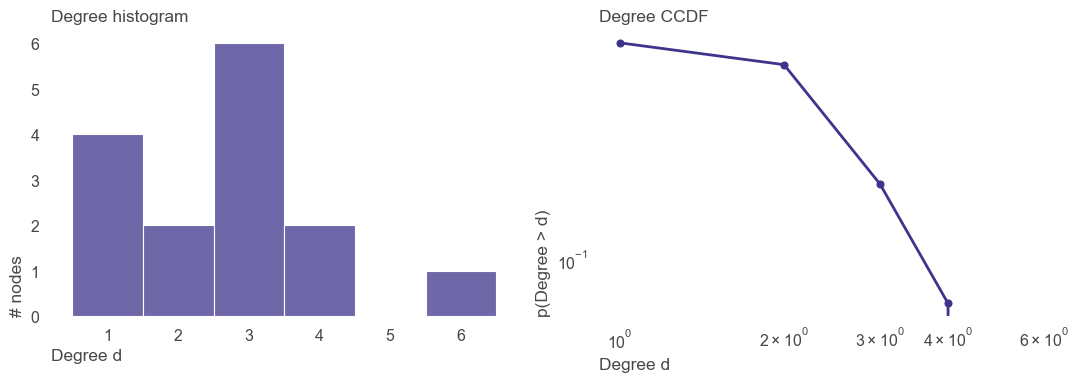

In [23]:
# Student scaffold: compare a histogram with a CCDF for degree.
# Small change to try: set `ccdf_scale = "linear"`.
from collections import Counter

def plot_ccdf(values, ax, xlabel="Degree d", ylabel="p(Degree > d)", marker="o-", scale="log"):
    C = Counter(values)
    xs, cnts = zip(*sorted(C.items()))
    cs = np.cumsum(cnts) / np.sum(cnts)
    ccdf = 1 - cs
    ax.plot(xs, ccdf, marker)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if scale == "log":
        ax.set_xscale("log")
        ax.set_yscale("log")

ccdf_scale = "log"
degree_values = g_flo.degree()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(degree_values, ax=axes[0], discrete=True, color=palette[0])
axes[0].set_xlabel("Degree d")
axes[0].set_ylabel("# nodes")
axes[0].set_title("Degree histogram")
plot_ccdf(degree_values, axes[1], scale=ccdf_scale)
axes[1].set_title("Degree CCDF")
plt.tight_layout()
plt.show()


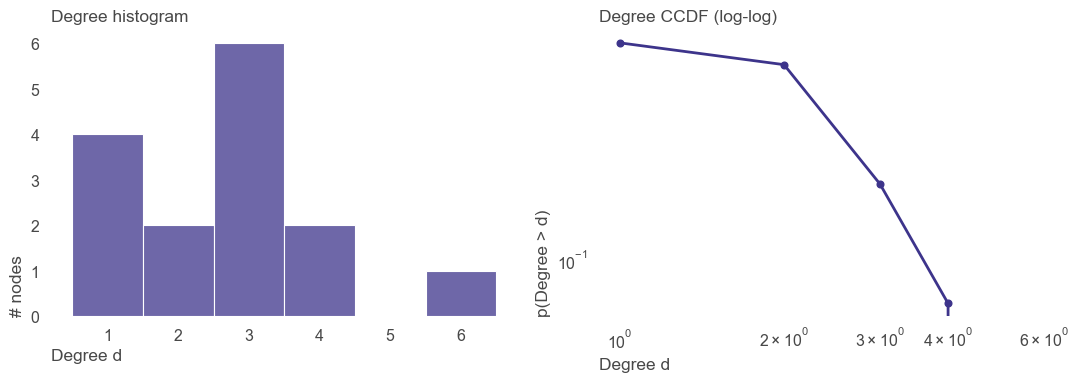

In [24]:
# Histogram + log-log CCDF of degree
degree_values = g_flo.degree()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(degree_values, ax=axes[0], discrete=True, color=palette[0])
axes[0].set_xlabel("Degree d")
axes[0].set_ylabel("# nodes")
axes[0].set_title("Degree histogram")

from collections import Counter
def plot_ccdf(values, ax, xlabel="Degree d", ylabel="p(Degree > d)", marker="o-", scale="log"):
    C = Counter(values)
    xs, cnts = zip(*sorted(C.items()))
    cs = np.cumsum(cnts) / np.sum(cnts)
    ccdf = 1 - cs
    ax.plot(xs, ccdf, marker)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if scale == "log":
        ax.set_xscale("log"); ax.set_yscale("log")

plot_ccdf(degree_values, axes[1])
axes[1].set_title("Degree CCDF (log-log)")
plt.tight_layout()
plt.show()


### 5.2 Triangles per node

`igraph` does not have a direct `triangles_per_node` function, but we can compute it cheaply from the adjacency matrix:

> The number of triangles a node `i` participates in is `(A^3)[i, i] / 2`.


In [25]:
# Student scaffold: triangles through a node come from the diagonal of A^3.
A_flo = np.array(g_flo.get_adjacency().data)
A3 = A_flo @ A_flo @ A_flo
triangles_per_node = (np.diag(A3) // 2).astype(int)

pd.DataFrame({
    "family": g_flo.vs["name"],
    "triangles": triangles_per_node,
}).sort_values("triangles", ascending=False)


,family,triangles
3,Peruzzi,2
4,Strozzi,2
1,Medici,1
2,Castellani,1
6,Ridolfi,1
7,Tornabuoni,1
11,Bischeri,1
0,Acciaiuoli,0
5,Barbadori,0
8,Albizzi,0


### 5.3 Local clustering coefficient

`g.transitivity_local_undirected()` returns one local clustering value per node.


,family,local_clustering
3,Peruzzi,0.666667
2,Castellani,0.333333
4,Strozzi,0.333333
6,Ridolfi,0.333333
7,Tornabuoni,0.333333
11,Bischeri,0.333333
1,Medici,0.066667
0,Acciaiuoli,0.000000
5,Barbadori,0.000000
8,Albizzi,0.000000


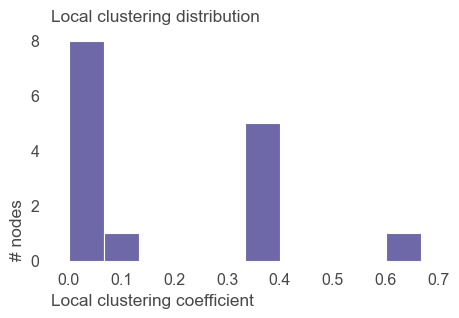

In [26]:
# Student scaffold: local clustering is one value per node.
local_clust = g_flo.transitivity_local_undirected(mode="zero")
clust_df = pd.DataFrame({"family": g_flo.vs["name"], "local_clustering": local_clust})
display(clust_df.sort_values("local_clustering", ascending=False))

sns.histplot(local_clust, bins=10, color=palette[0])
plt.xlabel("Local clustering coefficient")
plt.ylabel("# nodes")
plt.title("Local clustering distribution")
plt.show()


### 5.4 Shortest path lengths

`g.distances()` returns a full pairwise distance matrix. For large networks this is slow / memory-hungry.


Mean shortest path: 2.486
Diameter (max)    : 5


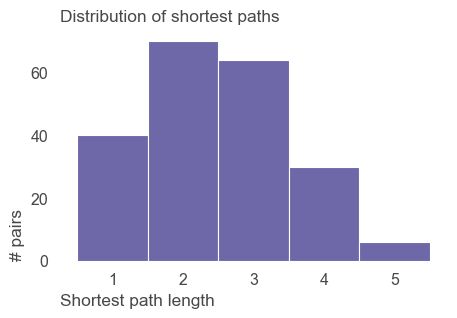

In [27]:
# Student scaffold: shortest paths are pairwise distances on the graph.
dist_matrix = np.array(g_flo.distances())
mask = np.isfinite(dist_matrix) & (dist_matrix > 0)
all_dists = dist_matrix[mask]
print(f"Mean shortest path: {all_dists.mean():.3f}")
print(f"Diameter (max)    : {int(all_dists.max())}")

sns.histplot(all_dists, discrete=True, color=palette[0])
plt.xlabel("Shortest path length")
plt.ylabel("# pairs")
plt.title("Distribution of shortest paths")
plt.show()


### 5.5 PDF, CDF and CCDF on log-log scale

A power-law degree distribution looks like a straight line on a log-log CCDF plot. Let's compare the degree distributions of the Wiki, Twitter and PPI networks.


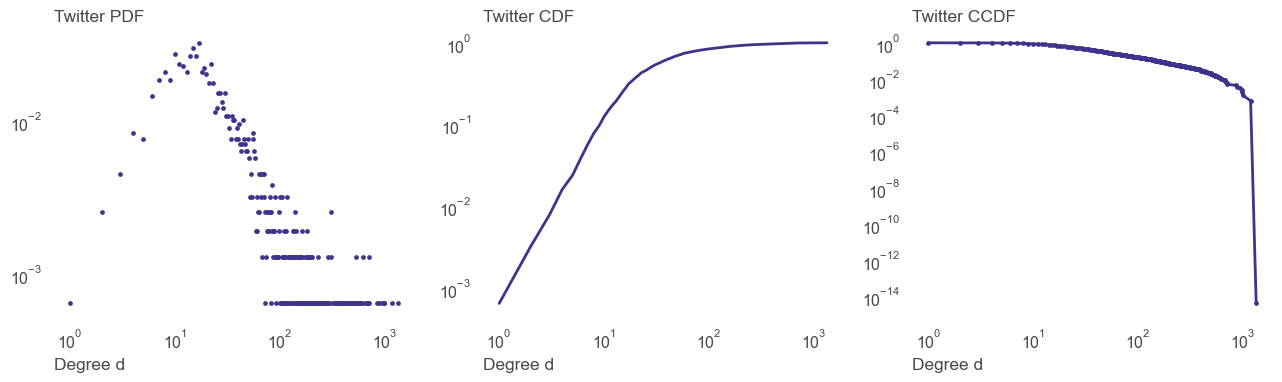

In [28]:
# Student scaffold: PDF/CDF/CCDF show different views of the same degree sequence.
# Small change to try: change `which_graph` to "twitter" or "ppi".
def plot_distributions(d, title="", scale="log"):
    C = Counter(d)
    xs, cnts = zip(*sorted(C.items()))
    pdf = np.array(cnts) / np.sum(cnts)
    cdf = np.cumsum(pdf)
    ccdf = 1 - cdf

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].plot(xs, pdf, ".")
    axes[0].set_title(f"{title} PDF")
    axes[1].plot(xs, cdf, "-")
    axes[1].set_title(f"{title} CDF")
    axes[2].plot(xs, ccdf, ".-")
    axes[2].set_title(f"{title} CCDF")
    for ax in axes:
        ax.set_xlabel("Degree d")
        if scale == "log":
            ax.set_xscale("log")
            ax.set_yscale("log")
    plt.tight_layout()
    plt.show()

which_graph = "twitter"  # try: "wiki", "twitter", "ppi"
graphs = {"wiki": G_wiki, "twitter": G_twitter, "ppi": G_ppi}
plot_distributions(graphs[which_graph].degree(), title=which_graph.title(), scale="log")


---

## Section 6: Reference models and permutation test

When we measure clustering = 0.19 on the Florentine network, the natural question is:

> **Is 0.19 high? Compared to what?**

The standard answer is to compare against a *reference model*: a random graph that preserves *some* property of the observed network (number of nodes, number of edges, degree sequence) but is otherwise random.


### 6.1 Three reference models

| Model | Preserves | igraph constructor |
|-------|-----------|--------------------|
| Erdos-Renyi (ER, `G(n, m)`) | n, m | `ig.Graph.Erdos_Renyi(n=..., m=...)` |
| Configuration model | full degree sequence | `ig.Graph.Degree_Sequence(...)` |
| Barabasi-Albert | preferential-attachment growth | `ig.Graph.Barabasi(...)` |


### 6.2 Visualise three reference graphs for the Florentine network


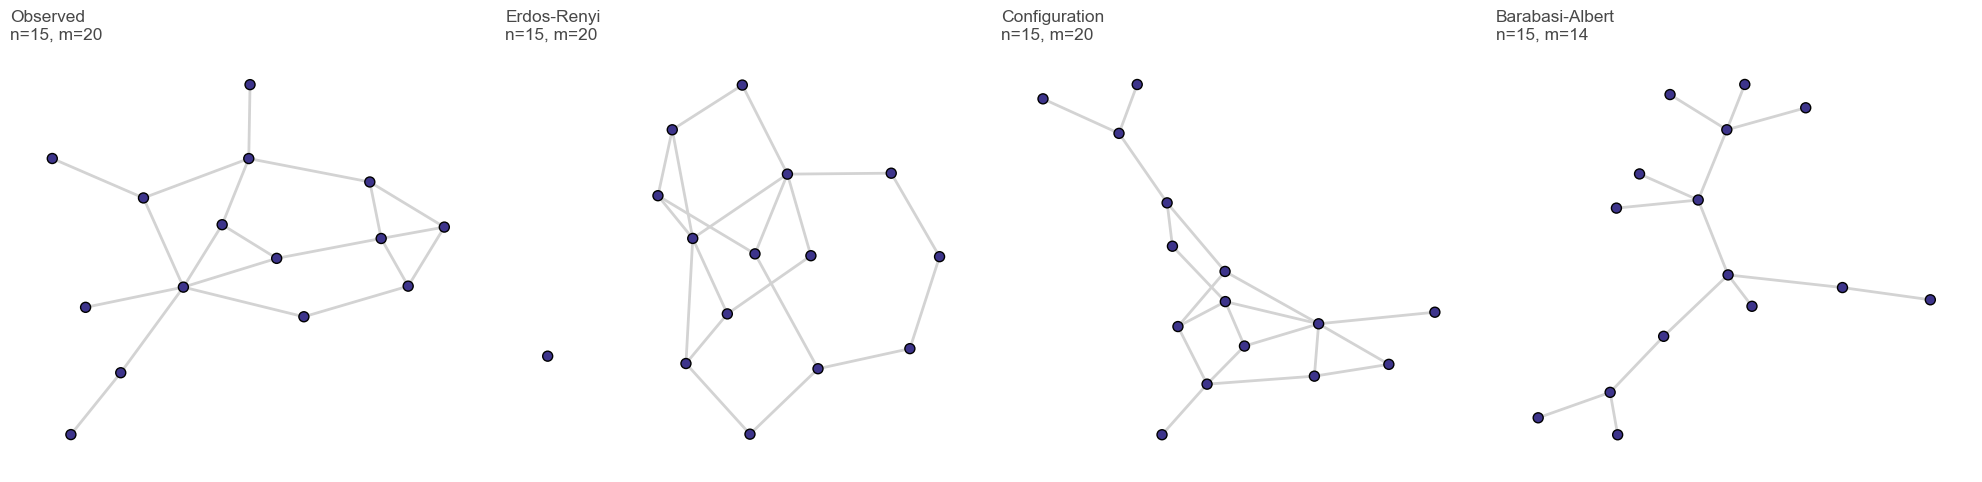

In [29]:
# Start with the Florentine network
n_flo = g_flo.vcount()
m_flo = g_flo.ecount()
deg_seq = g_flo.degree()


# Create baselines
G_er = ig.Graph.Erdos_Renyi(n=n_flo, m=m_flo, directed=False, loops=False)
G_cfg = ig.Graph.Degree_Sequence(deg_seq, method="vl")
G_ba = ig.Graph.Barabasi(n=n_flo, m=max(1, m_flo // n_flo), directed=False)

# Plot them
random.seed(1) # so the layout doesn't change if the network didn't change
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, gx) in zip(axes, [
    ("Observed", g_flo), ("Erdos-Renyi", G_er),
    ("Configuration", G_cfg), ("Barabasi-Albert", G_ba),
]):
    ig.plot(gx, target=ax, layout=gx.layout_fruchterman_reingold(),
            vertex_size=10, vertex_color="#3d348b", edge_color="lightgray")
    ax.set_title(f"{name}\nn={gx.vcount()}, m={gx.ecount()}")
plt.tight_layout()
plt.show()

# Reset to random seed
random.seed()

### 6.3 Confidence-interval comparison

We generate many random graphs of the same size, compute a metric on each, and compare the observed value to the 5%-95% percentile range.


In [30]:
def conf_int_ig(g_obs, fun, iters=100, model="er", seed=0):
    n = g_obs.vcount()
    m = g_obs.ecount()
    deg_seq = g_obs.degree()
    vals = []
    for _ in range(iters):
        if model == "er":
            Gr = ig.Graph.Erdos_Renyi(n=n, m=m, directed=False, loops=False)
        elif model == "config":
            Gr = ig.Graph.Degree_Sequence(deg_seq, method="vl")
        elif model == "ba":
            Gr = ig.Graph.Barabasi(n=n, m=max(1, m // n), directed=False)
        vals.append(fun(Gr))
    vals = np.array(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    return np.percentile(vals, [5, 95])

# small change: use #.assortativity_degree() instead
observed = g_flo.transitivity_undirected()
metric_fun = lambda G: G.transitivity_undirected()

print(f"Observed: {observed:.3f}")
for model in ["er", "config", "ba"]:
    lo, hi = conf_int_ig(g_flo, metric_fun, iters=100, model=model, seed=1)
    print(f"  {model:7s}: [{lo:.3f}, {hi:.3f}]")


Observed: 0.191
  er     : [0.065, 0.307]
  config : [0.064, 0.255]
  ba     : [0.000, 0.000]


### 6.4 Permutation test for attribute assortativity

The Florentine network can be annotated with a political faction: each family was either a **Medici** ally (`m`) or an **oligarch** (`o`). Do allied families marry each other more than chance would predict?

We test this by permuting the labels many times and comparing the observed assortativity to the null distribution.


Observed attribute assortativity: 0.2533


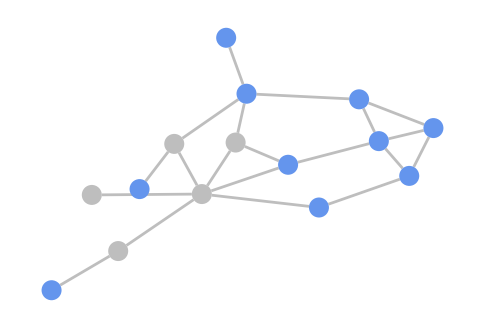

In [31]:
# Student scaffold: attach a simple political faction label to each family.
# Small change to try: change one family from "o" to "m" and rerun the test below.
ns_labels = ['Acciaiuoli', 'Medici', 'Castellani', 'Peruzzi', 'Strozzi', 'Barbadori',
             'Ridolfi', 'Tornabuoni', 'Albizzi', 'Salviati', 'Pazzi', 'Bischeri',
             'Guadagni', 'Ginori', 'Lamberteschi']
classes = ["m", "m", "o", "o", "o", "o", "o", "m", "m", "m", "o", "o", "o", "o", "o"]
name_to_class = dict(zip(ns_labels, classes))
g_flo.vs["faction"] = [name_to_class.get(name, "o") for name in g_flo.vs["name"]]

faction_int = [0 if c == "m" else 1 for c in g_flo.vs["faction"]]
node_color = ["gray" if c == "m" else "cornflowerblue" for c in g_flo.vs["faction"]]
obs_assort = g_flo.assortativity_nominal(types=faction_int, directed=False)
print(f"Observed attribute assortativity: {obs_assort:.4f}")

np.random.seed(0)
fig, ax = plt.subplots(figsize=(6,4))

ig.plot(
    g_flo,
    target=ax,
    layout=g_flo.layout_fruchterman_reingold(),
    vertex_color=node_color,
    vertex_size=20,
    vertex_frame_width=0,
    edge_color="gray"
)

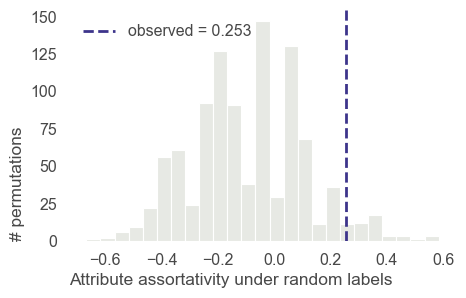

One-sided p-value (null >= observed): 0.0500


In [32]:
# Student scaffold: permutation test for "is this assortativity surprising?"
# Small change to try: set `iters = 10000` for a smoother histogram.
rng = np.random.default_rng(0)
iters = 1000
null_values = np.empty(iters)
faction_int_arr = np.array(faction_int)
for i in range(iters):
    permuted = rng.permutation(faction_int_arr)
    null_values[i] = g_flo.assortativity_nominal(types=permuted.tolist(), directed=False)

sns.histplot(null_values, binwidth=0.05, color=palette[3])
plt.axvline(obs_assort, ls="--", color=palette[0], label=f"observed = {obs_assort:.3f}")
plt.xlabel("Attribute assortativity under random labels")
plt.ylabel("# permutations")
plt.legend()
plt.show()

p_value = float(np.mean(null_values >= obs_assort))
print(f"One-sided p-value (null >= observed): {p_value:.4f}")


**Interpretation.** If the p-value is small (say < 0.05) we reject the null hypothesis that faction labels are independent of the marriage structure: families *did* preferentially marry within their political faction.

---

That's the end of practical 1a. You now have a working toolbox to:
1. Load a network from any common format.
2. Visualise it sensibly.
3. Describe it with numbers.
4. Plot its key distributions.
5. Test whether what you observe is "surprising" against a reasonable null.
